# Lista 1

## Zbiory danych

W projekcie wykorzystano dwa zbiory danych:
1. Telco Customer Churn – problem klasyfikacji (przewidywanie odejścia klienta)
2. Diamonds – problem regresji (przewidywanie ceny diamentu)

Zbiory zawierają zarówno cechy numeryczne, jak i kategorialne, co było wymagane w projekcie.

In [1]:

from copy import deepcopy

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from constants import (
    CATEGORICAL_COLUMNS,
    CHURN,
    CONTRACT,
    CUSTOMER_ID,
    DATA_FILE,
    DEPENDENTS,
    DEVICE_PROTECTION,
    GENDER,
    INTERNET_SERVICE,
    MONTHLY_CHARGES,
    MULTIPLE_LINES,
    NUMERIC_COLUMNS,
    ONLINE_BACKUP,
    ONLINE_SECURITY,
    PAPERLESS_BILLING,
    PARTNER,
    PAYMENT_METHOD,
    PHONE_SERVICE,
    STREAMING_MOVIES,
    STREAMING_TV,
    TECH_SUPPORT,
    TENURE,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Plik z danymi:", DATA_FILE)


Plik z danymi: resources\WA_Fn-UseC_-Telco-Customer-Churn.csv


## Załadowanie pliku

In [34]:
from sklearn.model_selection import train_test_split

data = pd.read_csv(DATA_FILE)

for column in NUMERIC_COLUMNS:
    data[column] = pd.to_numeric(data[column], errors="coerce")


# Podział na zbiór testowy i treningowy

Od tego momentu wszystkie decyzje dotyczące konstrukcji reguł, doboru progów i interpretacji cech opieram wyłącznie na zbiorze treningowym, zgodnie z zasadą unikania data leakage.

In [ ]:

train_df: pd.DataFrame
test_df: pd.DataFrame

train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data[CHURN])
display(train_df.head())    


# EDA
wstępna analiza danych 

In [ ]:

# obliczam tez statystiki ręcznie, bo tak było wymagane w etapie na 3.0
def numeric_statistics(df):
    numeric_data = df[NUMERIC_COLUMNS]

    statistics = pd.DataFrame(
        {
            "srednia": numeric_data.mean(),
            "mediana": numeric_data.median(),
            "min": numeric_data.min(),
            "max": numeric_data.max(),
            "odchylenie_standardowe": numeric_data.std(),
        }
    )

    return pd.DataFrame(statistics.round(2))


print("Pierwsze 5 wierszy:")
display(train_df.head())

print("Informacje o kolumnach:")
train_df.info()

print("Podstawowe statystyki dla cech numerycznych z pandas:")
display(train_df[NUMERIC_COLUMNS].describe().round(2))

print("podstawowe obliczone ręcznie statystkiki dla cech numerycznych")
display(numeric_statistics(train_df))



## Wybrane ciekawe zależności i dane

In [3]:
def tenure_histogram(df):
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=TENURE, bins=20, color="skyblue", edgecolor="black")
    plt.title("Histogram: czas trwania umowy")
    plt.xlabel("czas trwania umowy")
    plt.ylabel("Liczba klientow")
    plt.tight_layout()
    plt.show()


def tenure_churn_boxplot(df):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=CHURN, y=TENURE)
    plt.title("Boxplot: czas trwania umowy wzgledem rezygnacji")
    plt.xlabel("Rezygnacja")
    plt.ylabel("czas trwania umowy")
    plt.tight_layout()
    plt.show()


def monthly_charges_histogram(df):
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=MONTHLY_CHARGES, bins=20, color="orange", edgecolor="black")
    plt.title("Histogram: miesieczna oplata")
    plt.xlabel("miesieczna oplata")
    plt.ylabel("Liczba klientow")
    plt.tight_layout()
    plt.show()


def monthly_charges_churn_boxplot(df) :
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=CHURN, y=MONTHLY_CHARGES)
    plt.title("Boxplot: miesieczna oplata wzgledem rezygnacji")
    plt.xlabel("Rezygnacja")
    plt.ylabel("miesieczna oplata")
    plt.tight_layout()
    plt.show()


def tenure_monthly_charges_scatter(df):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=TENURE, y=MONTHLY_CHARGES, hue=CHURN, alpha=0.7)
    plt.title("Wykres rozrzutu: czas trwania umowy i miesieczna oplata")
    plt.xlabel("czas trwania umowy")
    plt.ylabel("miesieczna oplata")
    plt.legend(title="Rezygnacja")
    plt.tight_layout()
    plt.show()


### Uzasadnienie wyboru zmiennych i zależności
- `tenure` - pokazuje, jak dlugo klient korzysta z uslug. Nowi klienci zwykle czesciej rezygnuja.
- `MonthlyCharges` - pokazuje miesieczny koszt uslug. Wysoka oplata moze zwiekszac ryzyko odejscia.
- `tenure` vs `Churn` - pozwala sprawdzic, czy klienci odchodzacy maja krotszy czas korzystania z uslug.
- `MonthlyCharges` vs `Churn` - pokazuje, czy osoby odchodzace placa wiecej niz pozostali klienci.
- `tenure` vs `MonthlyCharges` - pozwala zobaczyc zaleznosc miedzy dlugoscia umowy i wysokoscia oplat.


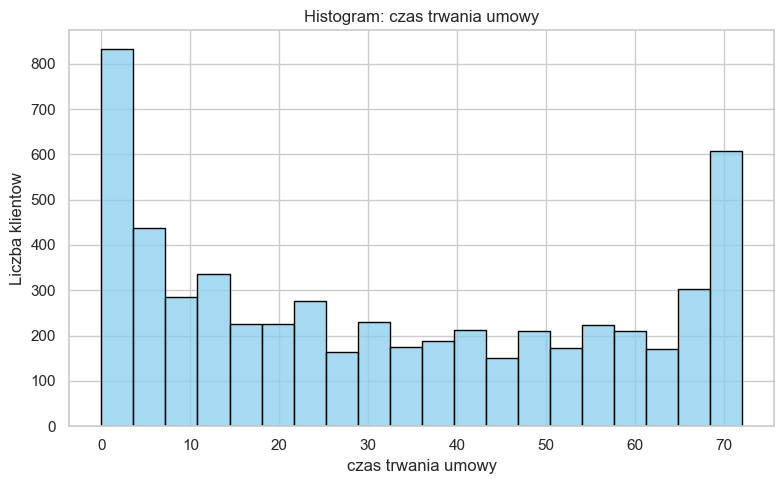

In [4]:
tenure_histogram(train_df)


**opis:**
Histogram wykazuje rozkład bimodalny. Najliczniejsze grupy stanowią nowi klienci (0-5 miesięcy) oraz klienci długoterminowi (powyżej 65 miesięcy).


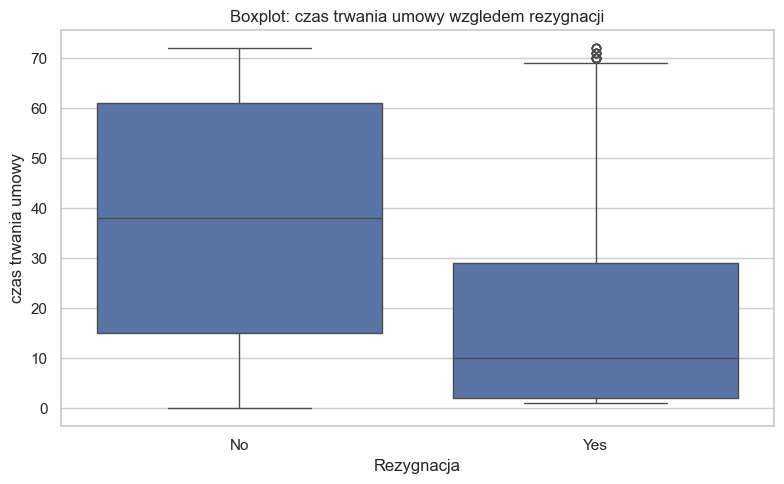

In [5]:
tenure_churn_boxplot(train_df)


**opis:** Mediana stażu umowy dla osób rezygnujących (ok. 10 mies.) jest drastycznie niższa niż dla osób pozostających (ok. 38 mies.). 75% wszystkich odejść następuje przed upływem 30 miesiąca trwania umowy.

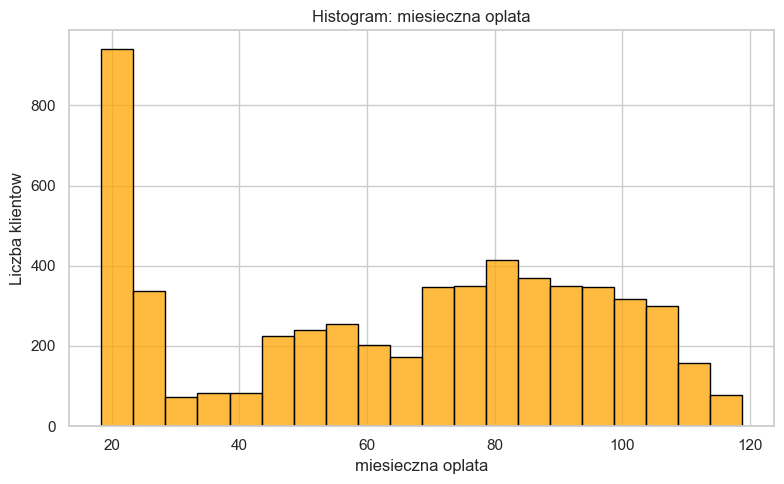

In [6]:
monthly_charges_histogram(train_df)


**opis:**  Wyraźna segmentacja klientów na dwie grupy: "Low-tier" (opłaty ok. 20 zł) oraz "High-tier" (opłaty 70-100 zł) Bardzo mała liczebność segmentu średniego (40-60 zł).
 

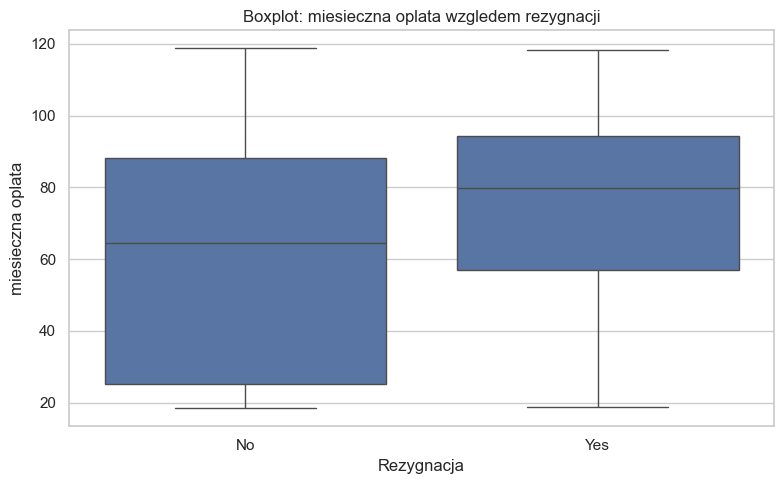

In [7]:
monthly_charges_churn_boxplot(train_df)


**opis:** Klienci rezygnujący płacą średnio o ok. 25% wyższe stawki miesięczne niż klienci lojalni (mediana ok. 80 zł vs 65 zł).

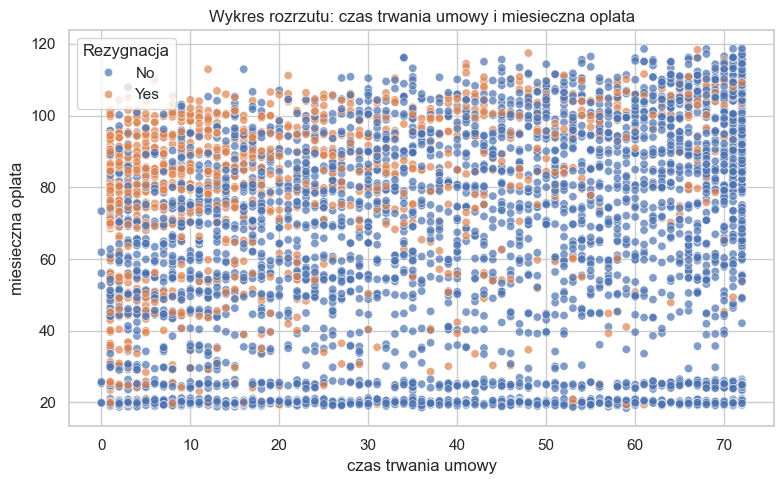

In [8]:
tenure_monthly_charges_scatter(train_df)


**opis:** Największa gęstość rezygnacji (punkty pomarańczowe) występuje w obszarze krótkiego stażu i wysokich opłat (lewy górny róg wykresu).

### końcowy wniosek z wykresów
Z Wykresów wynika, że najbardziej obiecujace cechy to `tenure` (czas trwania umowy) i `MonthlyCharges` (opłaty miesięczne), bezposrednio pokazuja, jak dlugo klient zostaje i ile placi. Cechy te mają największy wpływ na ryzyko rezygnacji klientów


## EDA na danych kategorialnych

In [9]:
categorial_df = train_df[CATEGORICAL_COLUMNS]


def get_categorial_stats(df):
    basic_stats = df.describe().round(2)
    top_prop = pd.DataFrame((basic_stats.loc['freq'] / basic_stats.loc['count'] * 100).round(2)).T
    top_prop.index = ['top_share_%']
    full_eda = pd.concat([basic_stats, top_prop], axis=0)
    return full_eda


categorial_df.info()
display(get_categorial_stats(categorial_df))


<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   gender            5634 non-null   str  
 1   Partner           5634 non-null   str  
 2   Dependents        5634 non-null   str  
 3   PhoneService      5634 non-null   str  
 4   MultipleLines     5634 non-null   str  
 5   InternetService   5634 non-null   str  
 6   OnlineSecurity    5634 non-null   str  
 7   OnlineBackup      5634 non-null   str  
 8   DeviceProtection  5634 non-null   str  
 9   TechSupport       5634 non-null   str  
 10  StreamingTV       5634 non-null   str  
 11  StreamingMovies   5634 non-null   str  
 12  Contract          5634 non-null   str  
 13  PaperlessBilling  5634 non-null   str  
 14  PaymentMethod     5634 non-null   str  
dtypes: str(15)
memory usage: 704.2 KB


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634,5634
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,2833,2905,3955,5075,2685,2483,2797,2442,2472,2771,2226,2217,3102,3331,1891
top_share_%,50.28,51.56,70.2,90.08,47.66,44.07,49.65,43.34,43.88,49.18,39.51,39.35,55.06,59.12,33.56


In [10]:

def plot_encoded_categorical_feature(
    df,
    column,
    title,
    tick_labels,
):
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=column, hue=CHURN)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Liczba klientow")
    plt.xticks(ticks=range(len(tick_labels)), labels=tick_labels, rotation=20)
    plt.tight_layout()
    plt.show()


selected_categorical_features = [
    CONTRACT,
    INTERNET_SERVICE,
    PAYMENT_METHOD,
    TECH_SUPPORT,
    ONLINE_SECURITY,
]




### Krotkie uzasadnienie doboru cech

- `Contract` - umowa miesieczna zwykle oznacza wieksze ryzyko rezygnacji i daje prostą regule decyzyjna.
- `InternetService` - rodzaj internetu moze wskazywac na roznice w cenie i jakosci uslugi.
- `PaymentMethod` - sposob platnosci czesto dzieli bardziej stabilnych i mniej stabilnych klientow.
- `TechSupport` - brak wsparcia technicznego moze zwiekszac frustracje i rezygnacje.
- `OnlineSecurity` - dodatkowe zabezpieczenia moga zmniejszac ryzyko odejscia klienta.


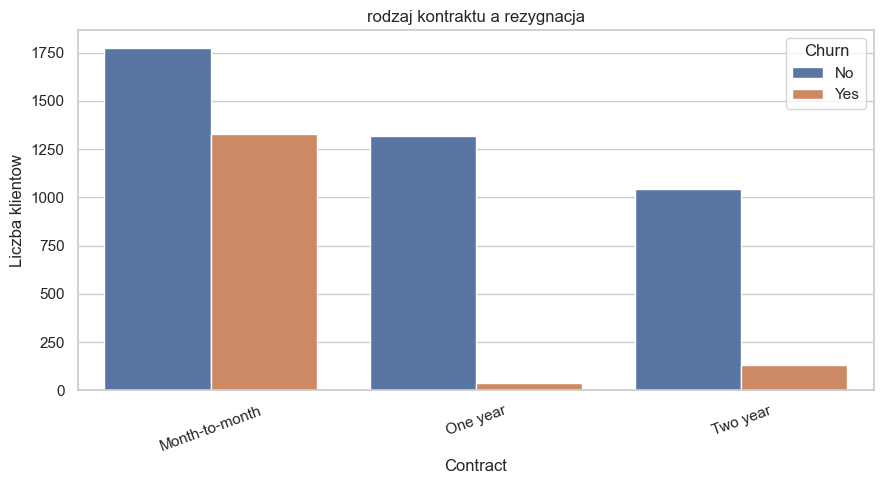

In [11]:
plot_encoded_categorical_feature(
	train_df,
	CONTRACT,
	"rodzaj kontraktu a rezygnacja",
	["Month-to-month", "One year", "Two year"],
)


**opis:** Typ umowy (Contract) wykazuje silną zależność z rezygnacją. Najwyższy wskaźnik Churn dotyczy umów Month-to-month, co potwierdza, że brak długoterminowego zobowiązania jest kluczowym predyktorem odejścia

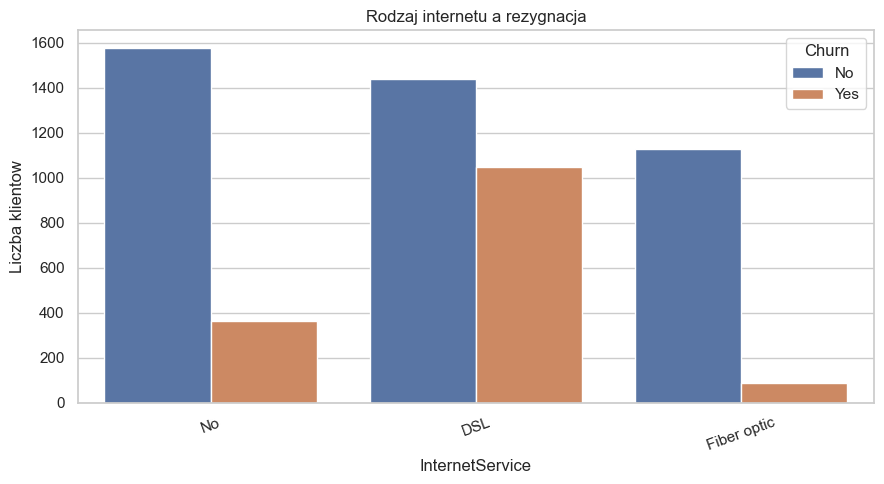

In [12]:
plot_encoded_categorical_feature(
    train_df,
    INTERNET_SERVICE,
    "Rodzaj internetu a rezygnacja",
    ["No", "DSL", "Fiber optic"],
)


**opis:** Użytkownicy Fiber optic (światłowód) odchodzą znacznie częściej niż pozostali. Liczba rezygnacji w tej grupie jest niemal zbliżona do liczby osób, które zostają. Z kolei osoby bez internetu (No) odchodzą sporadycznie.

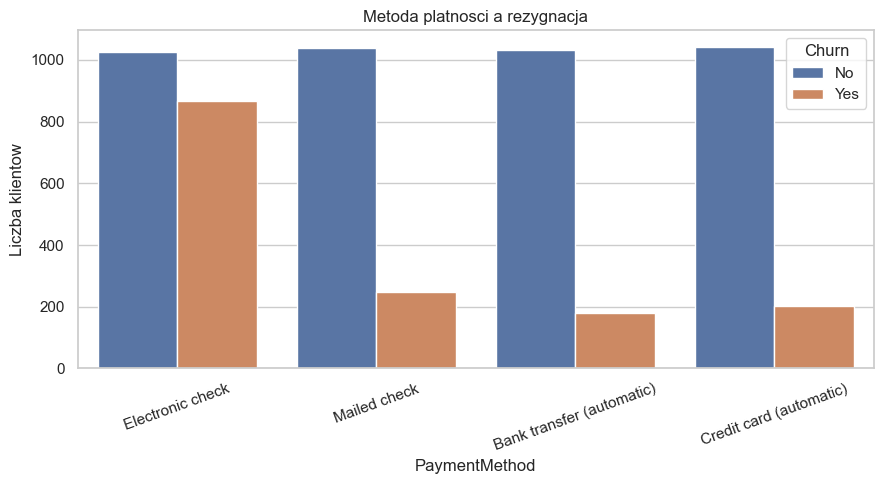

In [13]:
plot_encoded_categorical_feature(
    train_df,
    PAYMENT_METHOD,
    "Metoda platnosci a rezygnacja",
    ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"],
)


**opis:** Metoda Electronic check wyróżnia się na tle innych drastycznie wysokim słupkiem rezygnacji. Pozostałe metody (przelewy automatyczne czy karta) wykazują znacznie większą lojalność klientów.

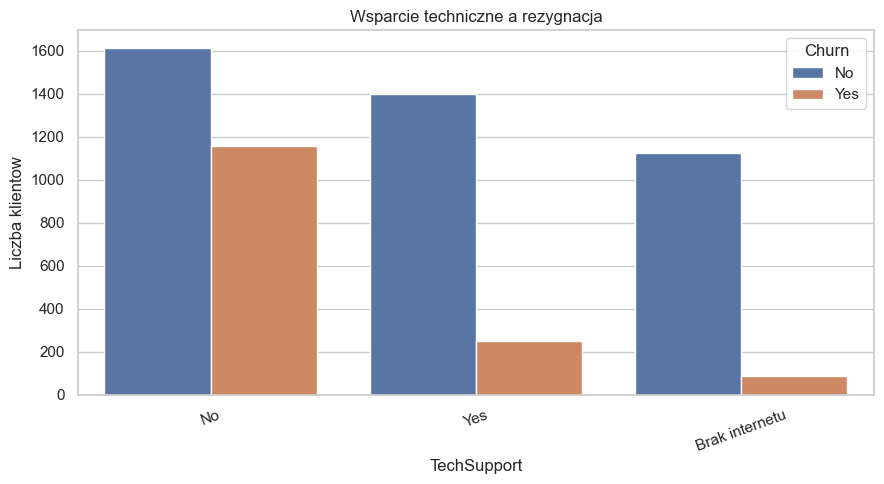

In [14]:
plot_encoded_categorical_feature(train_df,
                                 TECH_SUPPORT, 
                                 "Wsparcie techniczne a rezygnacja", 
                                 ["No", "Yes", "Brak internetu"])


**opis:** Osoby, które nie korzystają z wsparcia technicznego (No), rezygnują masowo. Z kolei klienci mający zapewniony TechSupport (Yes) odchodzą rzadko.

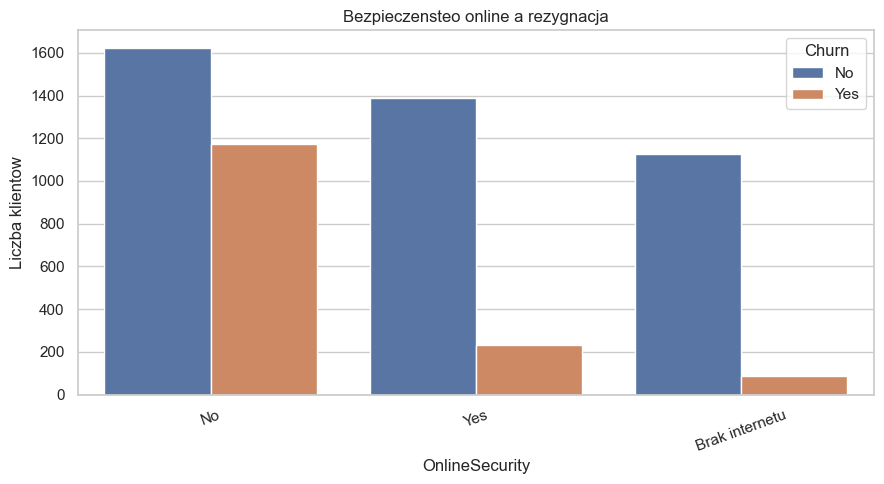

In [15]:
plot_encoded_categorical_feature(train_df,
                                 ONLINE_SECURITY, 
                                 "Bezpieczensteo online a rezygnacja", 
                                 ["No", "Yes", "Brak internetu"])


**opis:** Wykres jest niemal identyczny jak w przypadku TechSupport. Brak usługi OnlineSecurity drastycznie zwiększa prawdopodobieństwo rezygnacji.

## Kodowanie cech tekstowych na liczby
W tej czesci zamieniam wszystkie kolumny tekstowe z `train_df` na liczby. Dla prostych cech binarnych używam prostego ręcznego mapowania No=0, Yes=1, inna_opca = 2. Dla większej ilości możliwych wyników Uzywam `pd.factorize`, bo to najprostszy sposob, zeby zakodowac kazda wartosc stringowa na liczbe.

In [16]:

def apply_mapping(df, columns, mapping):
    for column in columns:
        if column in df.columns:
            df[column] = df[column].map(mapping)
    return df


def factorize_columns(
    train_frame,
    test_frame,
    columns,
    excluded_columns,
):
    mappings: dict[str, dict[str, int]] = {}
    useful_columns = [column for column in columns if column not in excluded_columns]

    for column in useful_columns:
        train_frame[column], unique_values = pd.factorize(train_frame[column])
        mappings[column] = {value: code for code, value in enumerate(unique_values)}

    for column, mapping in mappings.items():
        if column in test_frame.columns:
            test_frame[column] = test_frame[column].map(mapping)

    return train_frame, test_frame, mappings


encoded_train_df = train_df.copy()
encoded_test_df = test_df.copy()

string_columns = encoded_train_df.select_dtypes(include=["object", "string"]).columns.tolist()
string_columns = [column for column in string_columns if column != CUSTOMER_ID]

binary_cols = [PARTNER, DEPENDENTS, PAPERLESS_BILLING, PHONE_SERVICE, CHURN]
binary_cols_ns = [ONLINE_SECURITY, ONLINE_BACKUP, DEVICE_PROTECTION, TECH_SUPPORT, STREAMING_TV, STREAMING_MOVIES]
binary_cols_ps = [MULTIPLE_LINES]
factorized_cols = string_columns

binary_mapping = {"No": 0, "Yes": 1}
binary_mapping_ns = {"No": 0, "Yes": 1, "No internet service": 2}
binary_mapping_ps = {"No": 0, "Yes": 1, "No phone service": 2}

encoded_train_df = apply_mapping(encoded_train_df, binary_cols, binary_mapping)
encoded_test_df = apply_mapping(encoded_test_df, binary_cols, binary_mapping)

encoded_train_df = apply_mapping(encoded_train_df, binary_cols_ns, binary_mapping_ns)
encoded_test_df = apply_mapping(encoded_test_df, binary_cols_ns, binary_mapping_ns)

encoded_train_df = apply_mapping(encoded_train_df, binary_cols_ps, binary_mapping_ps)
encoded_test_df = apply_mapping(encoded_test_df, binary_cols_ps, binary_mapping_ps)

encoded_train_df, encoded_test_df, string_mappings = factorize_columns(
    encoded_train_df,
    encoded_test_df,
    factorized_cols,
    binary_cols + binary_cols_ns + binary_cols_ps,
)

print("Kolumny tekstowe zakodowane na liczby:")
print(string_columns)

display(encoded_train_df.head())
display(encoded_test_df.head())


Kolumny tekstowe zakodowane na liczby:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3738,4950-BDEUX,0,0,0,0,35,0,2,0,0,...,1,0,1,1,0,0,0,49.20,1701.65,0
3151,7993-NQLJE,0,0,1,1,15,1,0,1,1,...,0,0,0,0,0,0,1,75.10,1151.55,0
4860,7321-ZNSLA,0,0,1,1,13,0,2,0,1,...,0,1,0,0,1,0,1,40.55,590.35,0
3867,4922-CVPDX,1,0,1,0,26,1,0,0,0,...,1,0,1,1,1,1,2,73.50,1905.70,0
3810,2903-YYTBW,0,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,44.55,44.55,0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
437,4376-KFVRS,0,0,1,1,72,1,1,1,1,...,1,1,1,1,1,1,2,114.05,8468.20,0
2280,2754-SDJRD,1,1,0,0,8,1,1,1,0,...,0,1,1,1,0,1,2,100.15,908.55,0
2235,9917-KWRBE,1,0,1,1,41,1,1,0,1,...,1,0,1,0,2,1,2,78.35,3211.20,0
4460,0365-GXEZS,0,0,1,0,18,1,0,1,0,...,1,1,0,0,0,0,0,78.20,1468.75,0
3761,9385-NXKDA,1,0,1,0,72,1,1,0,1,...,1,0,1,1,1,1,2,82.65,5919.35,0


In [17]:
# wyswietlanie kodowania
mappings_wide = {}

for col, mapping in string_mappings.items():
    formatted_list = [f"{val} = {code}" for val, code in mapping.items()]
    mappings_wide[col] = formatted_list

max_len = max(len(v) for v in mappings_wide.values())
for col in mappings_wide:
    while len(mappings_wide[col]) < max_len:
        mappings_wide[col].append("")

mapping_table = pd.DataFrame(mappings_wide)

# Wyświetlamy
display(mapping_table.head())
display(encoded_train_df.head())


,gender,InternetService,Contract,PaymentMethod
0,Male = 0,DSL = 0,Month-to-month = 0,Electronic check = 0
1,Female = 1,Fiber optic = 1,Two year = 1,Mailed check = 1
2,,No = 2,One year = 2,Credit card (automatic) = 2
3,,,,Bank transfer (automatic) = 3


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3738,4950-BDEUX,0,0,0,0,35,0,2,0,0,...,1,0,1,1,0,0,0,49.20,1701.65,0
3151,7993-NQLJE,0,0,1,1,15,1,0,1,1,...,0,0,0,0,0,0,1,75.10,1151.55,0
4860,7321-ZNSLA,0,0,1,1,13,0,2,0,1,...,0,1,0,0,1,0,1,40.55,590.35,0
3867,4922-CVPDX,1,0,1,0,26,1,0,0,0,...,1,0,1,1,1,1,2,73.50,1905.70,0
3810,2903-YYTBW,0,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,44.55,44.55,0


## Pierwsza prosta reguła decyzyjna

Na podstawie wykresu `tenure` wybieram te ceche, bo bardzo wyraznie rozdziela klientow zostajacych i rezygnujacych.
Reguła bedzie bardzo prosta: jezeli klient ma krótki staż, przewiduj rezygnacje, w przeciwnym razie przewiduje brak rezygnacji. Do wyznaczenia wyznaczenia optymalnego progu decyzyjnego używam prostego algorytmu typu GridSearch, co pozwoliło na obiektywny dobór parametru nie kierując się subiektywnym spojrzeniem na wykresy


In [18]:
from sklearn.metrics import accuracy_score

y_train = encoded_train_df[CHURN]
y_test = encoded_test_df[CHURN]

possible_thresholds = range(1, 73)
best_threshold = 1
best_train_accuracy = 0.0

for threshold in possible_thresholds:
    train_predictions = (encoded_train_df[TENURE] < threshold).astype(int)
    current_accuracy = accuracy_score(y_train, train_predictions)

    if current_accuracy > best_train_accuracy:
        best_train_accuracy = current_accuracy
        best_threshold = threshold

print(f"Najlepszy prog dla tenure: {best_threshold}")
print(f"Accuracy na zbiorze treningowym: {best_train_accuracy:.4f}")

def predict(tenure: int, *args, **kwargs) -> int:
    if tenure < best_threshold:
        return 1
    return 0


Najlepszy prog dla tenure: 2
Accuracy na zbiorze treningowym: 0.7533


In [19]:
test_predictions = encoded_test_df[TENURE].apply(lambda value: predict(value))
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Accuracy na zbiorze testowym: {test_accuracy:.4f}")
display(pd.DataFrame({"prawdziwa_wartosc": y_test, "predykcja": test_predictions}).head(10))


Accuracy na zbiorze testowym: 0.7566


,prawdziwa_wartosc,predykcja
437,0,0
2280,0,0
2235,0,0
4460,0,0
3761,0,0
5748,0,0
3568,0,0
2976,0,0
5928,0,0
1639,1,0


### Wniosek

Uzyskany wynik Accuracy na poziomie 75,66% pokazuje, że nawet pojedyncza cecha tenure niesie istotną informację predykcyjną, choć sam wynik należy interpretować ostrożnie, ponieważ model jest bardzo uproszczony i opiera się tylko na jednym progu decyzyjnym.

Warto zauważyć, że próg 2 miesięcy został wybrany nie dlatego, że najlepiej opisuje cały rozkład odejść, lecz dlatego, że maksymalizuje Accuracy na zbiorze treningowym. Jest to próg bardzo konserwatywny — wychwytuje głównie najbardziej oczywiste przypadki szybkiej rezygnacji. Oznacza to, że metryka Accuracy może preferować węższy próg niż ten, który intuicyjnie wynika z boxplota.


# Złożony system decyzyjny

W rozbudowanej wersji systemu zidentyfikowałem 5 kluczowych scenariuszy ryzyka, opartych na statystycznych progach (mediana i 3 kwantyl):
Rezygnacja w przypadku gdy:
- Nowy klient jest na krótkiej umowie.
- Nowy klient z wysokimi kosztami
- umowa miesięczna i brak wsparcia
- długi staż klienta ale przepłacający

Brak rezygnacji gdy:
- Klienci są na kontraktach terminowych, którzy korzystają z usług dodatkowych



In [20]:
short_tenure_threshold = best_threshold
monthly_threshold = float(encoded_train_df[MONTHLY_CHARGES].median())
high_charge_threshold = float(encoded_train_df[MONTHLY_CHARGES].quantile(0.75))


def predict_complex(tenure, monthly_charges, contract, tech_support, online_security, *args, **kwargs) -> int:
    if tenure < short_tenure_threshold and contract == 0:
        return 1

    if tenure < short_tenure_threshold and monthly_charges >= monthly_threshold:
        return 1

    if contract == 0 and tech_support == 0 and online_security == 0:
        return 1

    if tenure >= short_tenure_threshold and contract == 0 and monthly_charges >= high_charge_threshold:
        return 1

    if contract != 0 and (tech_support == 1 or online_security == 1):
        return 0

    return 0


In [21]:
complex_test_predictions = encoded_test_df.apply(
    lambda row: predict_complex(
        row[TENURE],
        row[MONTHLY_CHARGES],
        row[CONTRACT],
        row[TECH_SUPPORT],
        row[ONLINE_SECURITY],
    ),
    axis=1,
)

complex_test_accuracy = accuracy_score(y_test, complex_test_predictions)

print(f"Accuracy prostego systemu: {test_accuracy:.4f}")
print(f"Accuracy rozbudowanego systemu: {complex_test_accuracy:.4f}")
print(f"Roznica: {complex_test_accuracy - test_accuracy:.4f}")
display(pd.DataFrame({"prawdziwa_wartosc": y_test, "predykcja": complex_test_predictions}).head(10))


Accuracy prostego systemu: 0.7566
Accuracy rozbudowanego systemu: 0.7410
Roznica: -0.0156


,prawdziwa_wartosc,predykcja
437,0,0
2280,0,1
2235,0,0
4460,0,0
3761,0,0
5748,0,1
3568,0,1
2976,0,0
5928,0,0
1639,1,1


### Wnioski z analizy (4.0 vs 4.5):
Rozbudowany system uzyskał 74.10% Accuracy, co stanowi spadek o 1.56% względem prostego modelu.
Przyczyny:
- Dominacja jednej cechy: Zmienna tenture jest tak silna, że dodatkowe warunki zamiast pomagać, wprowadzają szum informacyjny.
- Overfitting: Ręczne łączenie wielu cech (if/and) sprawiło, że model stał się zbyt specyficzny i przestał dobrze generalizować dane na zbiorze testowym.

 Wynik ten potwierdza, że proste systemy regułowe mają swoje limity, a dalsza poprawa skuteczności wymaga użycia algorytmów uczenia maszynowego (np. regresji), które lepiej wyważą znaczenie poszczególnych zmiennych.


# System rozwiązujący problem regresyjny
W celu demonstracji umiejętności budowy modeli regresyjnych, dokonano zmiany zbioru danych na diamonds. Wybór ten jest podyktowany naturą problemu – o ile zbiór Telco Churn służył do predykcji etykiet dyskretnych (klasyfikacja), o tyle zbiór diamonds pozwala na prognozowanie wartości numerycznych (cena). Pozwala to na zastosowanie metryk oceny modelu regresyjnego, takich jak MSE oraz MAE.

In [22]:

from sklearn.metrics import mean_absolute_error, mean_squared_error

from constants import (
    CARAT,
    CLARITY,
    COLOR,
    CUT,
    D_CATEGORIAL,
    D_NUMERIC,
    DEPTH,
    DIAMONDS_DATA_FILE,
    PRICE,
    TABLE,
    X,
    Y,
    Z,
)

diamonds_df = pd.read_csv(DIAMONDS_DATA_FILE)

for column in D_NUMERIC:
    diamonds_df[column] = pd.to_numeric(diamonds_df[column], errors="coerce")

print("Pierwsze 5 wierszy zbioru diamonds:")
display(diamonds_df.head())

print("Informacje o kolumnach:")
diamonds_df.info()

print("Podstawowe statystyki dla cech numerycznych:")
display(diamonds_df[D_NUMERIC].describe().round(2))


Pierwsze 5 wierszy zbioru diamonds:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Informacje o kolumnach:
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB
Podstawowe statystyki dla cech numerycznych:


,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


## EDA dla cech kategorialnych

W zbiorze `diamonds` najważniejsze cechy kategorialne to `cut`, `color` i `clarity`. To one najczęściej pomagają wyjaśnić różnice w cenie diamentu.


In [23]:

diamonds_categorial_df = diamonds_df[D_CATEGORIAL]


def get_diamonds_categorial_stats(df: pd.DataFrame) -> pd.DataFrame:
    basic_stats = df.describe().round(2)
    top_share = (basic_stats.loc['freq'] / len(df) * 100).round(2)
    top_share_df = pd.DataFrame(top_share).T
    top_share_df.index = ['top_share_%']
    full_eda = pd.concat([basic_stats, top_share_df], axis=0)
    
    return full_eda


display(get_diamonds_categorial_stats(diamonds_categorial_df))



,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065
top_share_%,39.95,20.93,24.22


## 5 najciekawszych cech

- `carat` - zwykle najsilniej wpływa na cenę.
- `cut` - jakość szlifu może podnosić lub obniżać cene.
- `color` - kolor jest ważny przy wycenie diamentów.
- `clarity` - przejrzystość również mocno różnicuje ceny.
- `depth` / `table` - dodatkowe parametry geometryczne mogą doprecyzować wycenę.


In [24]:
def plot_numeric_histogram(df: pd.DataFrame, column: str, title: str) -> None:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, bins=30, color="#4C78A8", edgecolor="black")
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Liczba obserwacji")
    plt.tight_layout()
    plt.show()


def plot_boxplot_vs_price(df: pd.DataFrame, column: str, title: str) -> None:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=column, y=PRICE)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("price")
    plt.tight_layout()
    plt.show()


def plot_scatter_vs_price(df: pd.DataFrame, column: str, title: str) -> None:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=column, y=PRICE, alpha=0.35)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("price")
    plt.tight_layout()
    plt.show()




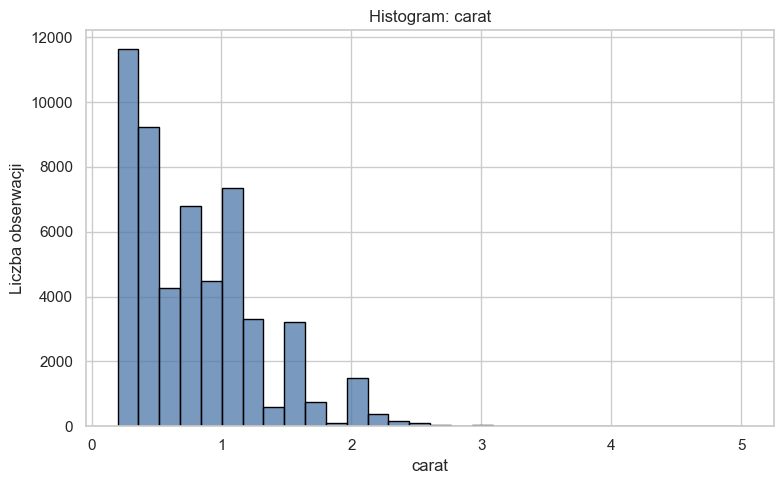

In [25]:
plot_numeric_histogram(diamonds_df, CARAT, "Histogram: carat")


**opis**: Wykres przedstawia rozkład masy diamentów w karatach. Widzimy bardzo silną skośność prawostronną – ogromna większość kamieni ma masę poniżej 1 karata.

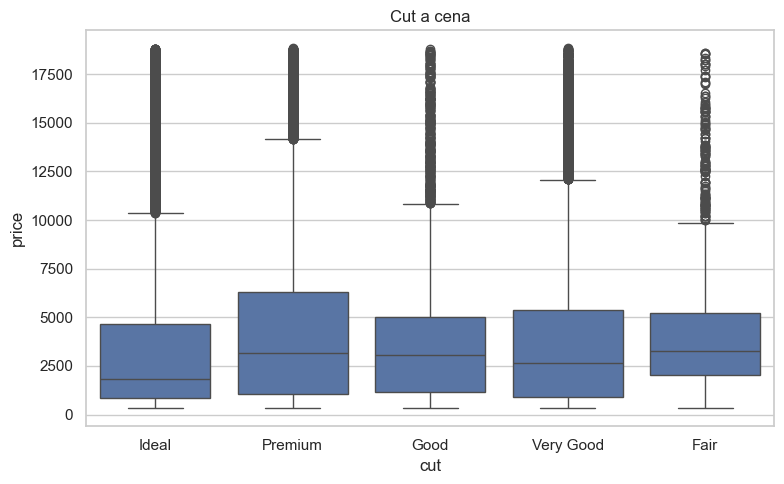

In [26]:
plot_boxplot_vs_price(diamonds_df, CUT, "Cut a cena")


**opis**: Wykres pokazuje zależność ceny od jakości szlifu (od Fair do Ideal). Zauważalny jest paradoks – średnia cena dla szlifu Ideal (najlepszego) wydaje się być niższa niż dla szlifu Premium czy nawet Fair.

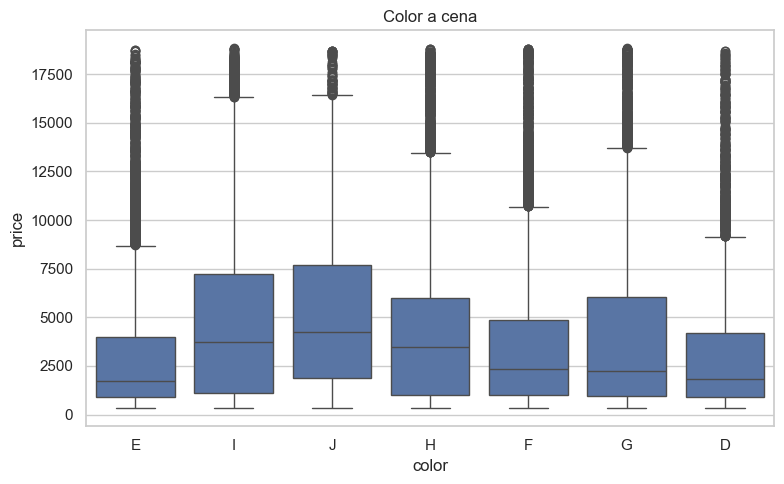

In [27]:
plot_boxplot_vs_price(diamonds_df, COLOR, "Color a cena")


**opis**: Porównanie cen diamentów w zależności od ich barwy. Ponownie widzimy trend wzrostowy ceny w stronę gorszych kolorów (I, J). 

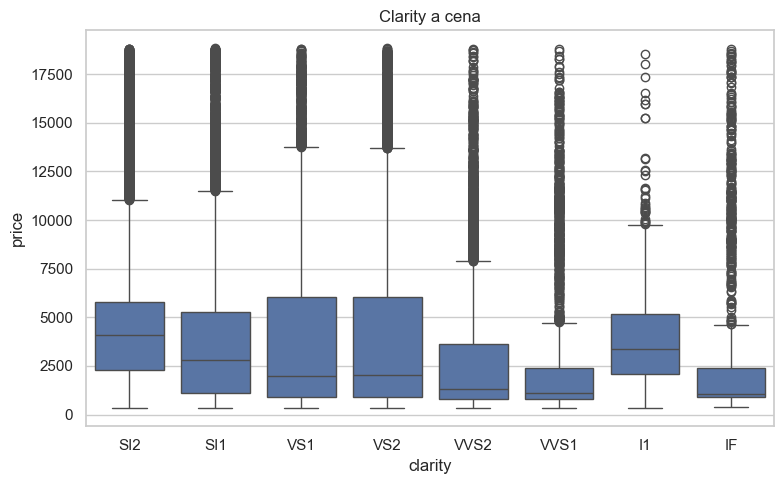

In [28]:
plot_boxplot_vs_price(diamonds_df, CLARITY, "Clarity a cena")


**opis**: Najwyższe ceny (i najwięcej wartości odstających) obserwujemy dla czystości SI1, SI2 oraz VS2. Klasy najwyższe (IF, VVS1) mają niższe mediany cen.

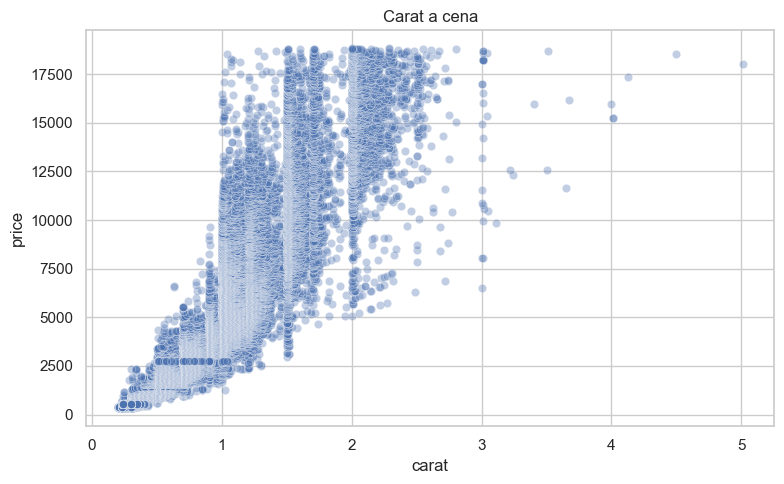

In [29]:
plot_scatter_vs_price(diamonds_df, CARAT, "Carat a cena")


**opis**: Wzrost ceny diamentu nie jest liniowy – wraz ze wzrostem masy (carat) cena rośnie coraz szybciej. Dla większych wartości karata obserwuje się większy rozrzut cen, co wskazuje, że oprócz masy istotną rolę zaczynają odgrywać inne cechy, takie jak jakość szlifu, kolor oraz czystość diamentu

## Podział na trening i test

Po wstępnej analizie dzielę zbiór na część treningową i testową.


In [30]:
diamonds_train_df, diamonds_test_df = train_test_split(
    diamonds_df,
    test_size=0.2,
    random_state=42,
)

display(diamonds_train_df.head())


,carat,cut,color,clarity,depth,table,price,x,y,z
26546,2.01,Good,F,SI2,58.1,64.0,16231,8.23,8.19,4.77
9159,1.01,Very Good,E,SI2,60.0,60.0,4540,6.57,6.49,3.92
14131,1.10,Premium,H,VS2,62.5,58.0,5729,6.59,6.54,4.10
15757,1.50,Good,E,SI2,61.5,65.0,6300,7.21,7.17,4.42
24632,1.52,Very Good,G,VS1,62.1,57.0,12968,7.27,7.32,4.53


## Prosty system regresyjny

Jako główny wyznacznik ceny przyjąłem wagę diamentu (carat). Model najpierw segmentuje dane na trzy grupy cenowe (niską, średnią i wysoką) przy użyciu kwantyli (0.25 i 0.75). Pozwala to na ustalenie stabilnej bazy cenowej, która jest odporna na skrajne wartości odstające. 
Cena bazowa jest następnie dynamicznie korygowana o autorskie wagi procentowe:
- Bonus +20% dla diamentów łączących najlepszy szlif (cut) z najbardziej pożądaną barwą (color).
- Dodatkowe +5% dla kamieni o najwyższej przejrzystości (clarity).
- Obniżka ceny o 15% dla szlifów o niskiej jakości, które obniżają estetykę i wartość inwestycyjną kamienia.


In [31]:
carat_low = diamonds_train_df[CARAT].quantile(0.25)
carat_high = diamonds_train_df[CARAT].quantile(0.75)

low_price = diamonds_train_df[diamonds_train_df[CARAT] < carat_low][PRICE].mean()
mid_price = diamonds_train_df[(diamonds_train_df[CARAT] >= carat_low)
                              & (diamonds_train_df[CARAT] < carat_high)][PRICE].mean()
high_price = diamonds_train_df[diamonds_train_df[CARAT] >= carat_high][PRICE].mean()


def safe_mean(value: float) -> float:
    if pd.isna(value):
        return float(diamonds_train_df[PRICE].mean())
    return float(value)


low_price = safe_mean(low_price)
mid_price = safe_mean(mid_price)
high_price = safe_mean(high_price)


def predict_regression(carat, cut, color, clarity, **kwargs):
    if carat < carat_low:
        price = low_price
    elif carat < carat_high:
        price = mid_price
    else:
        price = high_price

    if cut in ["Ideal", "Premium"] and color in ["D", "E", "F"]:
        price = price * 1.20

    if cut in ["Fair", "Good"]:
        price = price * 0.85

    if clarity in ["IF", "VVS1", "VVS2"]:
        price = price * 1.05

    return float(price)


In [32]:
train_predictions_reg = diamonds_train_df.apply(
    lambda row: predict_regression(
        row[CARAT],
        row[CUT],
        row[COLOR],
        row[CLARITY],
    ),
    axis=1,
)

test_predictions_reg = diamonds_test_df.apply(
    lambda row: predict_regression(
        row[CARAT],
        row[CUT],
        row[COLOR],
        row[CLARITY],
    ),
    axis=1,
)

mse_train = mean_squared_error(diamonds_train_df[PRICE], train_predictions_reg)
mae_train = mean_absolute_error(diamonds_train_df[PRICE], train_predictions_reg)
mse_test = mean_squared_error(diamonds_test_df[PRICE], test_predictions_reg)
mae_test = mean_absolute_error(diamonds_test_df[PRICE], test_predictions_reg)

print(f"Train MSE: {mse_train:.2f}")
print(f"Train MAE: {mae_train:.2f}")
print(f"Test MSE: {mse_test:.2f}")
print(f"Test MAE: {mae_test:.2f}")


Train MSE: 5947148.69
Train MAE: 1648.96
Test MSE: 5903829.97
Test MAE: 1628.79


### interpretacja
Zaimplementowany model regresji uzyskał średni błąd bezwzględny (MAE) na poziomie 1628.79 $ na zbiorze testowym. Kluczowym wnioskiem jest wysoka stabilność modelu – błąd na danych testowych jest niemal identyczny jak na danych treningowych, co wyklucza zjawisko przeuczenia. Model poprawnie wychwytuje główny trend cenowy zależny od masy (carat), a wysoka wartość metryki MSE wynika z naturalnej dla tego zbioru obecności wartości odstających (bardzo drogich diamentów o unikalnych cechach), które są trudniejsze do precyzyjnego oszacowania prostym systemem regułowym

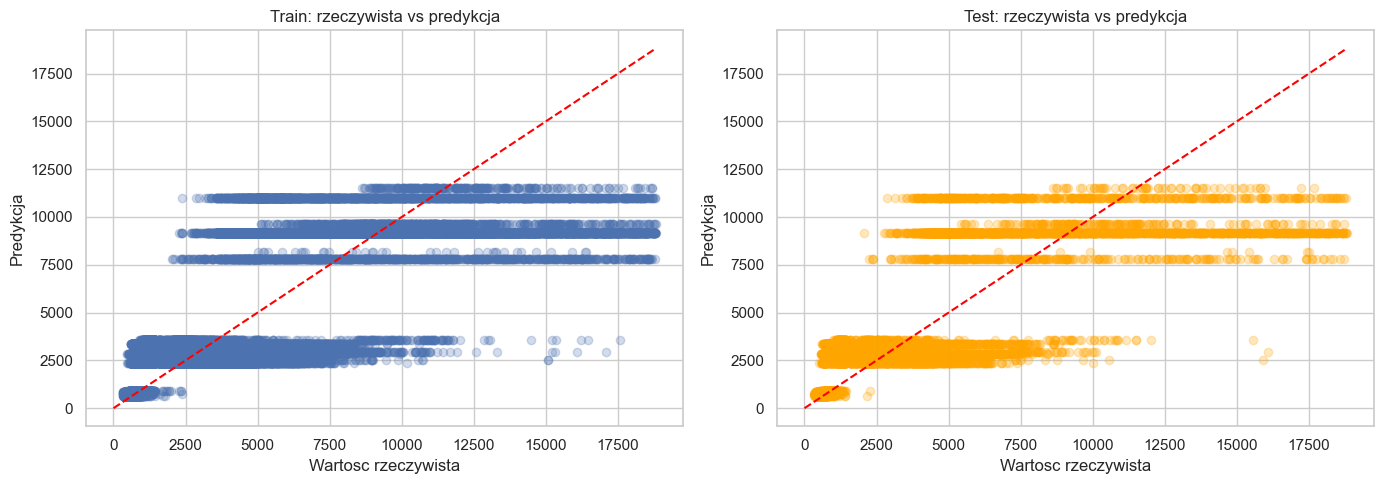

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(diamonds_train_df[PRICE], train_predictions_reg, alpha=0.25)
axes[0].plot([0, diamonds_train_df[PRICE].max()], [0, diamonds_train_df[PRICE].max()], color="red", linestyle="--")
axes[0].set_title("Train: rzeczywista vs predykcja")
axes[0].set_xlabel("Wartosc rzeczywista")
axes[0].set_ylabel("Predykcja")

axes[1].scatter(diamonds_test_df[PRICE], test_predictions_reg, alpha=0.25, color="orange")
axes[1].plot([0, diamonds_test_df[PRICE].max()], [0, diamonds_test_df[PRICE].max()], color="red", linestyle="--")
axes[1].set_title("Test: rzeczywista vs predykcja")
axes[1].set_xlabel("Wartosc rzeczywista")
axes[1].set_ylabel("Predykcja")

plt.tight_layout()
plt.show()


# interpretacja wykresów regresji
Widoczne na wykresach poziome linie to dowód na to, że model przypisuje diamenty do konkretnych "koszyków" cenowych. Nie wylicza on ceny co do dolara, lecz uśrednia ją dla grup (np. "mały-tani", "duży-drogi").

Model wyraźnie "boi się" wysokich cen. Powyżej 12 500 $ wszystkie punkty uciekają nad moją predykcję. Oznacza to, że moje ręczne reguły są zbyt zachowawcze i nie doszacowują unikalnych, najdroższych kamieni.

Ręczne projektowanie reguł było wykonalne tylko dlatego, że liczba cech była ograniczona i dało się wizualnie wskazać kilka najważniejszych zależności. Przy zbiorze zawierającym np. 1000 cech pojawiłby się problem eksplozji liczby możliwych kombinacji warunków, trudności w doborze progów, niskiej interpretowalności oraz bardzo dużego ryzyka przeuczenia. To właśnie dlatego w praktyce stosuje się klasyczne modele ML, które potrafią automatycznie wybierać istotne zależności i lepiej generalizować na nowe dane.